# This file plots the normalized hysteresis area for H+ ion concentrations

author: Eike E. Köhn ......
date: July 29, 2025 ......
instructions: can be run with environment "conda env:pangeo-meso-2024.01.22" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Decide if figures are to be saved (and if so the directory)

In [2]:
savefigs = True
plot_dir = Plotter._get_plot_dir('review_round_1')

## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr()  #Params.test_set_1pctCO2cdr() #

Setting parameters...


## Choose the variable that is to be analyzed - and its temporal resolution

In [4]:
print('Choosing variable and temporal resolution....')
variable_to_analyze = 'hplus'
depth_to_analyze = 'surface'
temporal_resolution = 'annual_means'

Choosing variable and temporal resolution....


## Get the model data for the variable of choice

In [5]:
print("Getting the variable's model dataset...")
run_paths = ModelDataGetter._identify_path_strings(run_params,variable_to_analyze,depth_to_analyze)
ds_data   = ModelDataGetter._open_datasets(run_paths)

Getting the variable's model dataset...


## Since the loaded data is pH and not H+, i need to convert here. In the same process i convert the H+ data already to nmol kg-1. Attention to not use run_paths afterwards anymore since this is still pointing to pH data.

In [6]:
ds_data = ModelDataGetter._convert_ph_to_hplus(ds_data)
del run_paths # deleting here run_paths for safety reasons

## Get the additional ocean mask, area weights, atmospheric CO2, and ocean regions

In [7]:
print('Getting miscellaneous data...')
da_omask  = MiscDataGetter._get_ocean_mask()
da_area   = MiscDataGetter._get_grid_cell_areas()
ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)
ds_oregs, reg_lookup_dict  = MiscDataGetter._get_ocean_regions()

Getting miscellaneous data...
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account th

## Compute the hysteresis area for the variable of choice - and compute the multimodel mean and agreements

In [8]:
hyst_dict = HystFuncs._calc_hysteresis_areas_3D_multimodel(run_params,ds_data,temporal_resolution,ds_atmCO2)

Calculating hysteresis area for model UKESM1-0-LL (key 2)...
Calculating hysteresis area for model NorESM2-LM (key 3)...
Calculating hysteresis area for model MIROC-ES2L (key 4)...
Calculating hysteresis area for model CNRM-ESM2-1 (key 5)...
Calculating hysteresis area for model ACCESS-ESM1-5 (key 6)...
Calculating hysteresis area for model CESM2 (key 7)...
Calculating hysteresis area for model CanESM5 (key 8)...
Calculating hysteresis area for model GFDL-ESM4 (key 9)...


In [9]:
print('Calculating multimodel mean and model agreement ...')
h_mmm,  h_agree  = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='hysteresis_area',            agreement_type='mean_bigger_than_std')
hn_mmm, hn_agree = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='normalized_hysteresis_area', agreement_type='mean_bigger_than_std')
hs_mmm, hs_agree = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='signed_hysteresis_area', agreement_type='sign', agreement_thresh='at_least_80percent_agree')

Calculating multimodel mean and model agreement ...


## Pick example locations and regions for local analysis

In [10]:
set_of_loc_reg = MiscDataGetter._standard_set_of_regions_locations()
print('Chosen locations: ', set_of_loc_reg)

Chosen locations:  ['Global Ocean', [88, 260], [60, 90], 'central Arctic']


## Plot the multimodel mean normalized hysteresis area for the variable as a global map

Plot the multimodel mean hysteresis areas - globally....


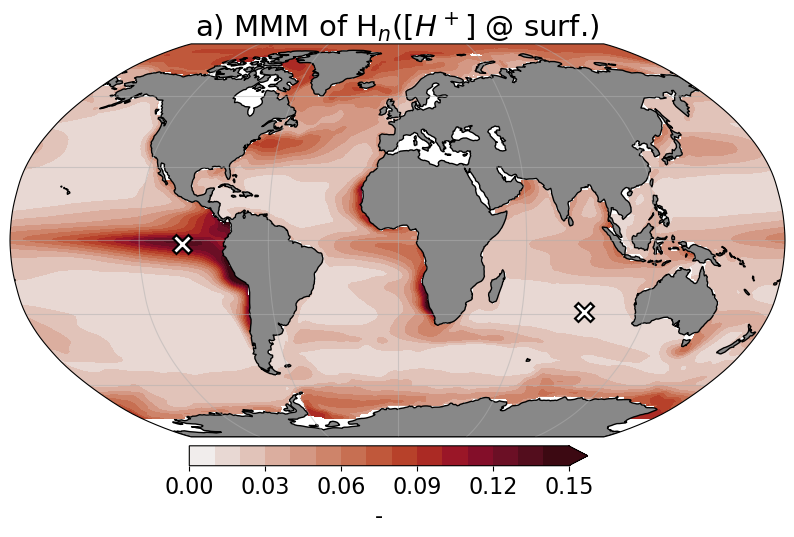

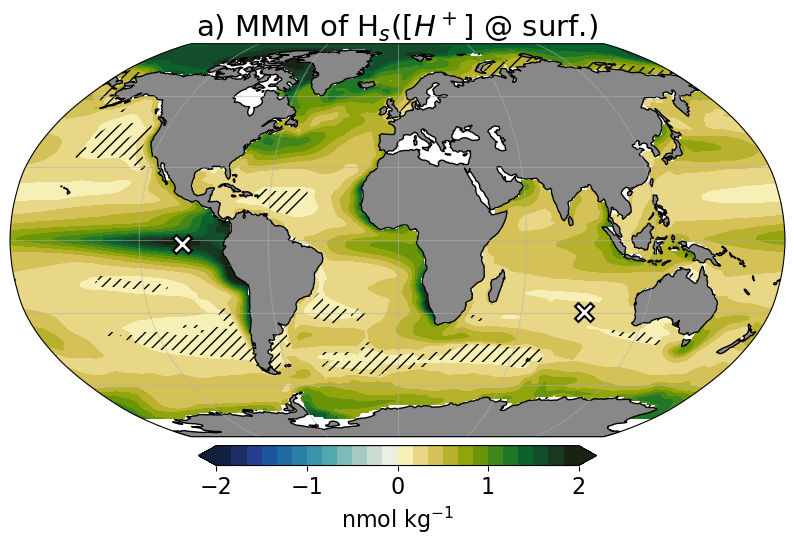

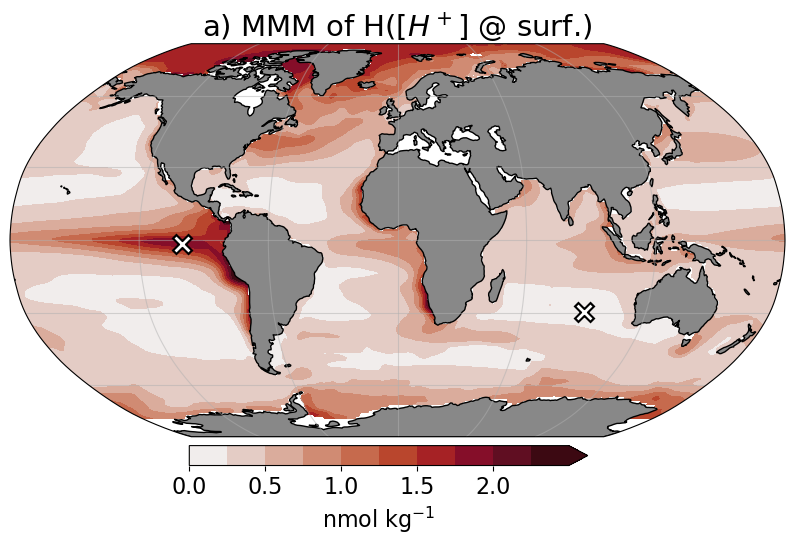

In [11]:
print('Plot the multimodel mean hysteresis areas - globally....')

fig, ax = Plotter.plot_global_map(hn_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=0.15,
                                  nlevs=16,
                                  cmap=plt.get_cmap('cmo.amp',15),
                                  cticks = [0,.030,.060,.090,.120,.150],
                                  extend='max',
                                  clabel='-',
                                  title=r'a) MMM of H$_n$($[H^+]$ @ surf.)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_normalized_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_global_map(hs_mmm,
                                  set_of_loc_reg,
                                  vmin=-2,
                                  vmax=2,
                                  nlevs=25,
                                  cticks = [-2,-1,0,1,2],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.delta',24),
                                  extend='both',
                                  clabel='nmol kg$^{-1}$',
                                  title=r'a) MMM of H$_s$($[H^+]$ @ surf.)',
                                  agreement=hs_agree)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_signed_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_global_map(h_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=2.5,
                                  nlevs=11,
                                  cticks = [0,.5,1,1.5,2],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.amp',10),
                                  extend='max',
                                  clabel=r'nmol kg$^{-1}$',
                                  title=r'a) MMM of H($[H^+]$ @ surf.)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_full_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)



## Plot the multimodel mean normalized hysteresis area for the variable as an Arctic map

Plot the multimodel mean hysteresis areas - for the Arctic....


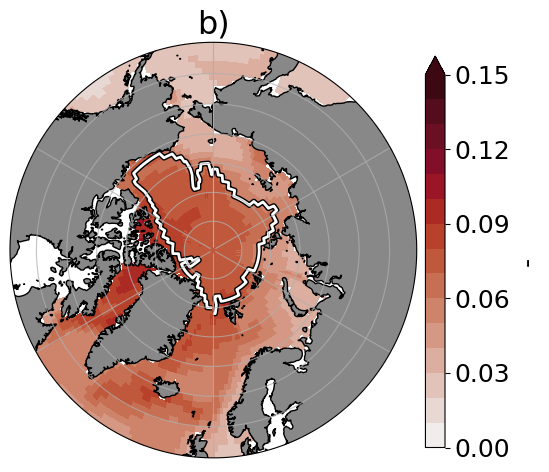

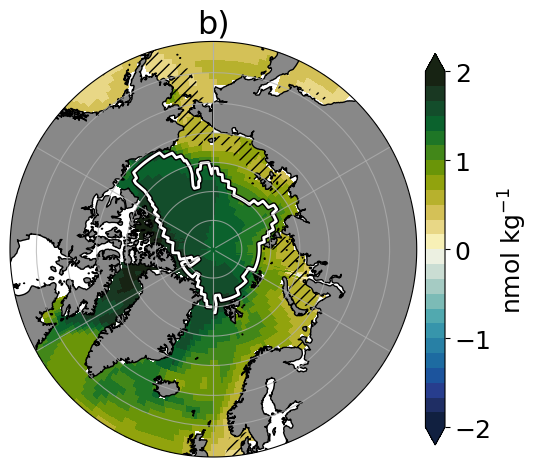

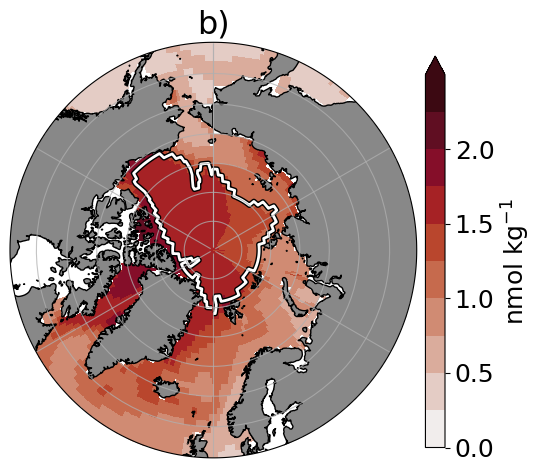

In [12]:
print('Plot the multimodel mean hysteresis areas - for the Arctic....')

fig, ax = Plotter.plot_arctic_map(hn_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=.150,
                                  nlevs=16,
                                  cmap=plt.get_cmap('cmo.amp',15),
                                  cticks = [0,.030,0.060,0.090,.120,.150],
                                  extend='max',
                                  clabel='-',
                                  title=r'b)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_normalized_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)

fig, ax = Plotter.plot_arctic_map(hs_mmm,
                                  set_of_loc_reg,
                                  vmin=-2,
                                  vmax=2,
                                  nlevs=25,
                                  cticks = [-2,-1,0,1,2],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.delta',24),
                                  extend='both',
                                  clabel='nmol kg$^{-1}$',
                                  title=r'b)',
                                  agreement=hs_agree)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_signed_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)

fig, ax = Plotter.plot_arctic_map(h_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=2.5,
                                  nlevs=11,
                                  cticks = [0,.5,1,1.5,2],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.amp',10),
                                  extend='max',
                                  clabel=r'nmol kg$^{-1}$',
                                  title=r'b)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_full_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


## Compute regional mean or extract point location time series of the variable of choice

In [13]:
print('Get time series....')
regional_time_series = MMFuncs._calc_regional_means(run_params,set_of_loc_reg,ds_data,temporal_resolution)

Get time series....


## Plot the timeseries (against atmospheric CO2) at the chosen locations

Plot the timeseries against atmospheric CO2 at four different locations....


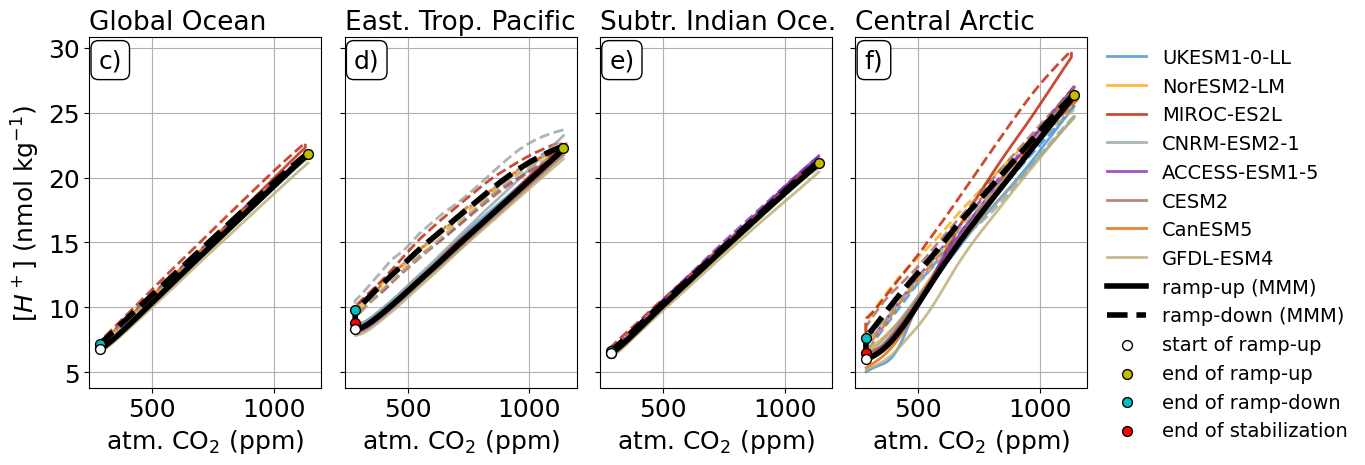

In [14]:
def plot_four_timeseries_against_atmCO2(run_params,regional_time_series,ds_atmCO2,set_of_loc_reg):

    panel_labels = ['c','d','e','f']
    up_index_all = []
    dn_index_all = []
    rampup_val_all = []
    rampdn_val_all = []
    
    start_val_all = []
    end_val_all = []
    diff_val_all = []

    fontsize=18
    fig, ax = plt.subplots(1,len(set_of_loc_reg),figsize=(14,5),sharey=True)

    # loop over regions
    for idx,loc_or_reg in enumerate(set_of_loc_reg):
        # loop over runs
        data_to_plot_all = [] 
        for key in run_params.keys():
            
            # Get the CO2 
            atmCO2 = ds_atmCO2[key]
            rampup_atmCO2   = atmCO2.isel(year=slice(0,  140))
            rampdown_atmCO2 = atmCO2.isel(year=slice(140,340))

            # Get the data
            # First, get the right region string
            if isinstance(loc_or_reg,str):
                loc_or_reg_string = loc_or_reg
            elif isinstance(loc_or_reg,list):
                loc_or_reg_string = f'point_{loc_or_reg[0]}_{loc_or_reg[1]}'
            else:
                raise Exception('Not yet implemented')
            
            # Now get the data and smooth it for better readability
            reg_time_series = regional_time_series[loc_or_reg_string][key]
            data_to_plot_all.append(reg_time_series)

            rampup_timeseries   = Spliner.fspline1D(reg_time_series.isel(year=slice(0,  140)),0.06)
            rampdown_timeseries = Spliner.fspline1D(reg_time_series.isel(year=slice(140,340)),0.06)

            # Plot the rampup
            ax[idx].plot(rampup_atmCO2,   rampup_timeseries,   color=run_params[key].runcol, zorder=4, linewidth=2, label=run_params[key].model, alpha=.8)
            # Plot the rampdown
            ax[idx].plot(rampdown_atmCO2, rampdown_timeseries, color=run_params[key].runcol, zorder=4, linewidth=2, linestyle='--',alpha=.8)

        mmm = xr.concat(data_to_plot_all,dim='keys').mean(dim='keys')#.mean(data_to_plot_all,axis=0)

        # smooth the rampup and rampdown separately (to avoid a smoothing of the peak)
        mmm_rup = mmm.isel(year=slice(0,  140))
        mmm_rdn = mmm.isel(year=slice(140,340))
        
        mmm_rup_smooth = Spliner.fspline1D(mmm_rup,0.06)
        mmm_rdn_smooth = Spliner.fspline1D(mmm_rdn,0.06)

        mmm_rampup = xr.DataArray(data = mmm_rup_smooth, coords = mmm_rup.coords, dims = mmm_rup.dims)
        mmm_rampdown = xr.DataArray(data = mmm_rdn_smooth, coords = mmm_rdn.coords, dims = mmm_rdn.dims)

        # Plot the MMM rampup
        ax[idx].plot(rampup_atmCO2,   mmm_rampup, color='k',zorder=4,linewidth=4,label='ramp-up (MMM)',alpha=1)
        # Plot the MMM rampdown
        ax[idx].plot(rampdown_atmCO2, mmm_rampdown, color='k',zorder=4,linestyle='--',label='ramp-down (MMM)',linewidth=4,alpha=1)

        # Scatter points at imprtant times
        ax[idx].scatter(atmCO2.isel(year=0),  mmm.isel(year=0),  50,facecolor='w',edgecolor='k',marker='o',zorder=6,label='start of ramp-up')
        ax[idx].scatter(atmCO2.isel(year=140),mmm.isel(year=140),50,facecolor='y',edgecolor='k',marker='o',zorder=5,label='end of ramp-up')
        ax[idx].scatter(atmCO2.isel(year=280),mmm.isel(year=280),50,facecolor='c',edgecolor='k',marker='o',zorder=5,label='end of ramp-down')
        ax[idx].scatter(atmCO2.isel(year=339),mmm.isel(year=339),50,facecolor='r',edgecolor='k',marker='o',zorder=4,label='end of stabilization')
    
        ax[idx].grid()
        ax[idx].set_xlabel('atm. CO$_2$ (ppm)')
        ax[idx].text(0.04,0.915,panel_labels[idx]+')',transform=ax[idx].transAxes,bbox={'boxstyle':'round','fc':'w'})#indices_titles[idx],loc='left')
        plt.subplots_adjust(wspace=0.03)
        ax[0].set_ylabel(r'$[H^+]$ (nmol kg$^{-1}$)')
        if loc_or_reg_string == 'central Arctic':
            ax[idx].legend(fontsize=fontsize-4,loc='lower left',bbox_to_anchor=(1.01,-0.2),edgecolor='w')
        
        if loc_or_reg_string == 'point_88_260':
            title_string ='East. Trop. Pacific'
        elif loc_or_reg_string == 'point_60_90':
            title_string = 'Subtr. Indian Oce.'
        elif loc_or_reg_string == 'central Arctic':
            title_string = 'Central Arctic'
        else:
            title_string = loc_or_reg_string

        ax[idx].set_title(title_string,loc='left',fontsize=fontsize+1)
    
        #for axi in ax:
            #axi.axhline(1,linestyle=':',color='#555555',linewidth=2)
            #axi.set_ylim([0.2,4.1])
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.1)
        
    return fig, ax #


print('Plot the timeseries against atmospheric CO2 at four different locations....')
fig, ax = plot_four_timeseries_against_atmCO2(run_params,regional_time_series,ds_atmCO2,set_of_loc_reg) 
#print('Rampup crossing 1 at XX ppm:', rampup_val_all)
#print('Rampdown crossing 1 at XX ppm:', rampdn_val_all)
if savefigs == True:
    fig.savefig(f'{plot_dir}/time_series_against_co2_4regions_{variable_to_analyze}.png',dpi=300,transparent=True)


## Compute regional mean hysteresis areas of the variable of choice

In [15]:
print('Compute the regional hysteresis areas....')
regional_mean_normalized_hysteresis_areas = MMFuncs._calc_regional_means(run_params,set_of_loc_reg, hyst_dict, 'normalized_hysteresis_area')
regional_mean_signed_hysteresis_areas = MMFuncs._calc_regional_means(run_params,set_of_loc_reg, hyst_dict, 'signed_hysteresis_area')

Compute the regional hysteresis areas....


In [16]:
all_central = []
all_global = []
for key in ['2','3','4','5','6','7','8','9']:
    all_central.append(regional_mean_normalized_hysteresis_areas['central Arctic'][key].values)
    all_global.append(regional_mean_normalized_hysteresis_areas['Global Ocean'][key].values)
print('Central Arctic average of normalized hysteresis area:')
print(f'{np.mean(all_central)} +- {np.std(all_central)}')
print('Global Ocean average of normalized hysteresis area:')
print(f'{np.mean(all_global)} +- {np.std(all_global)}')


Central Arctic average of normalized hysteresis area:
0.07440036251189112 +- 0.027056313355840234
Global Ocean average of normalized hysteresis area:
0.03170104666056263 +- 0.007306429777809713


## Save the central Arctic hysteresis areas

In [17]:
region_to_save = 'central Arctic'
ds_hn = regional_mean_normalized_hysteresis_areas[region_to_save]
ds_hs = regional_mean_signed_hysteresis_areas[region_to_save]
              
ds_hn.attrs['unit'] = 'ppm'
ds_hn.attrs['name'] = 'normalized hysteresis area'
ds_hn.attrs['region'] = f'{region_to_save}'

ds_hs.attrs['unit'] = '-'
ds_hs.attrs['name'] = 'signed hysteresis area'
ds_hs.attrs['region'] = f'{region_to_save}'

############### SAVE THE AMOC hysteresis areas #################
ds_hn.to_netcdf(f'../07_plots_datasets_for_review_round1/fig01_{variable_to_analyze}_{region_to_save}_normalized_hysteresis_area.nc')
ds_hs.to_netcdf(f'../07_plots_datasets_for_review_round1/fig01_{variable_to_analyze}_{region_to_save}_signed_hysteresis_area.nc')

## Save the global hysteresis area maps

In [18]:
hyst_types = ['hysteresis_area','signed_hysteresis_area','normalized_hysteresis_area']
run_names = list(run_params.keys())  # or hyst_dict.keys()
hyst_ds = xr.Dataset()

for hyst_type in hyst_types:
    data_list = [hyst_dict[run][hyst_type] for run in run_names]

    # Ensure the data has a consistent dimension name (e.g., "run")
    hyst_da = xr.concat(data_list, dim='run')
    hyst_da = hyst_da.assign_coords(run=("run", run_names))

    # Add to dataset
    hyst_ds[hyst_type] = hyst_da

hyst_ds.to_netcdf(f'../07_plots_datasets_for_review_round1/fig05_{variable_to_analyze}_hysteresis_area_global_map.nc')

# Some supplementary plots

## First, calculate time series for chosen regions

In [19]:
set_of_loc_reg_2 = ['Global Ocean','Arctic Ocean','Barents Sea','central Arctic']
print('Chosen locations: ', set_of_loc_reg_2)
regional_time_series_2 = MMFuncs._calc_regional_means(run_params,set_of_loc_reg_2,ds_data,temporal_resolution)

Chosen locations:  ['Global Ocean', 'Arctic Ocean', 'Barents Sea', 'central Arctic']


## Plot the central Arctic time series against time, fancy

Plot the regional time series, but in fancy....


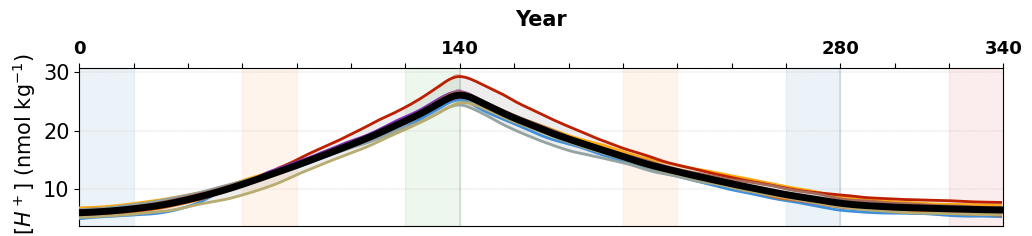

In [20]:
print('Plot the regional time series, but in fancy....')
fig, ax = Plotter._plot_regional_time_series_fancy(run_params,regional_time_series_2,'central Arctic',variable_to_analyze,' $[H^+]$ (nmol kg$^{-1}$)',include_atmCO2=False)
if savefigs == True:
    fig.savefig(f'{plot_dir}/time_series_against_time_1region_fancy_{variable_to_analyze}.png',dpi=300,transparent=True)


## Now plot the time slice averages, including for the piControl

Setting parameters...
Opening the variable's model dataset...
Convert the pic data
Compute time slice averages.....
Now plot the time slice....


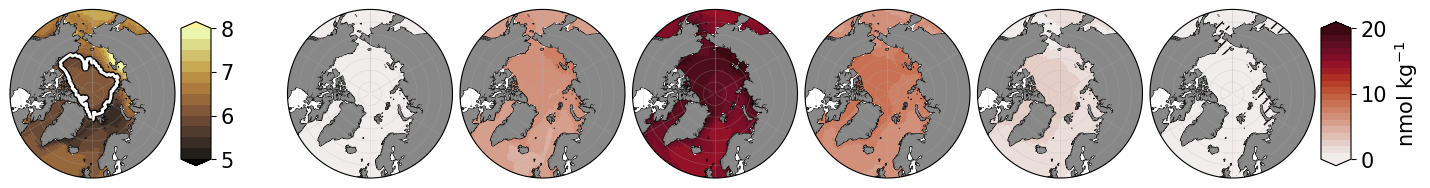

In [21]:
print('Setting parameters...')
pic_params = Params.standard_set_piControl() #Params.test_set_1pctCO2cdr()  #

print("Opening the variable's model dataset...")
pic_paths = ModelDataGetter._identify_path_strings(pic_params,variable_to_analyze,depth_to_analyze)
pic_data   = ModelDataGetter._open_datasets(pic_paths)

print("Convert the pic data")
pic_data = ModelDataGetter._convert_ph_to_hplus(pic_data)
del pic_paths # deleting here run_paths for safety reasons

print('Compute time slice averages.....')
time_slices='standard'
time_slice_type='anom_to_preindustrial_initial'
time_slice_averages_mmm, time_slice_averages_agreement = MMFuncs._calc_time_slice_averages(ds_data,pic_data,temporal_resolution,time_slices=time_slices,time_slice_type=time_slice_type)

print('Now plot the time slice....')
# set colormaps and units
cmap = plt.get_cmap('cmo.turbid_r',12);cmap.set_over('#faf798');cmap.set_under('k')
amap = plt.get_cmap('cmo.amp',20);#amap.set_under('m')
fig, ax = Plotter._plot_time_slice_averages(time_slice_averages_mmm,time_slice_averages_agreement,time_slice_type='anom_to_preindustrial_initial',
                                   vmin=5,vmax=8,
                                   cmap=cmap,
                                   amin=0,amax=20,
                                   amap=amap,
                                   unit='nmol kg$^{-1}$',
                                   include_region_mask='central Arctic')

if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_time_slice_averages_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)

## Now plot the normalized hysteresis areas, but for each model separately

Plot the hysteresis areas for the individual models.....


/home/ekoehn/jobs/jupyter/arctic_acidification_reversibility/03_analysis_and_plotting/../00_modules/./funcs_for_plotting.py:326: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


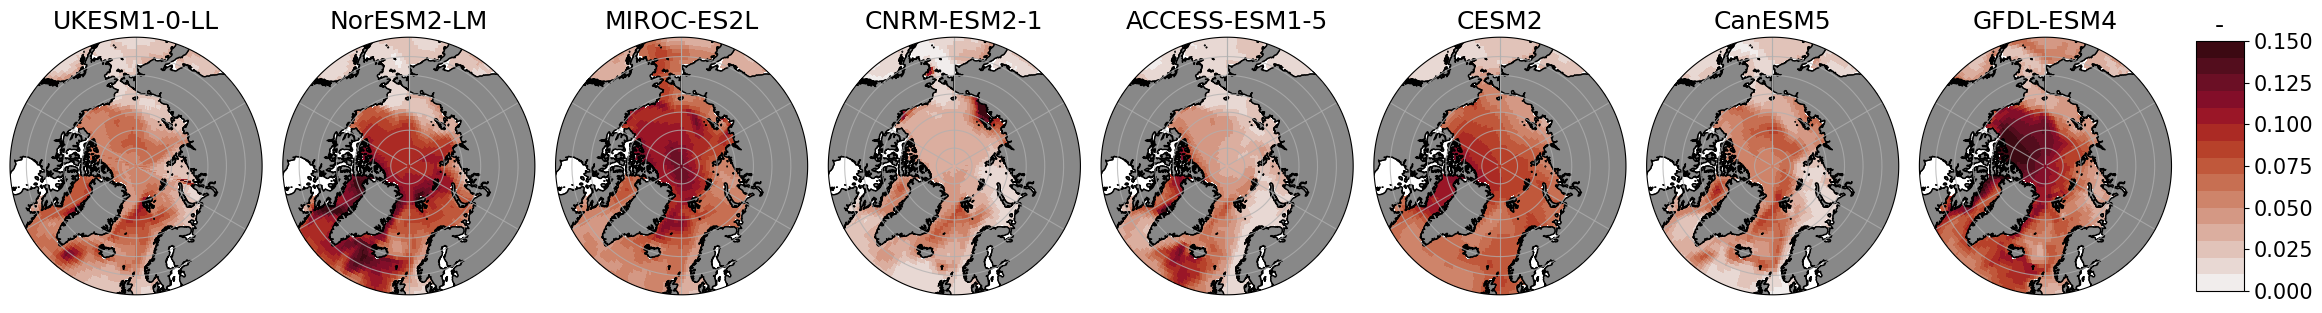

/home/ekoehn/jobs/jupyter/arctic_acidification_reversibility/03_analysis_and_plotting/../00_modules/./funcs_for_plotting.py:326: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


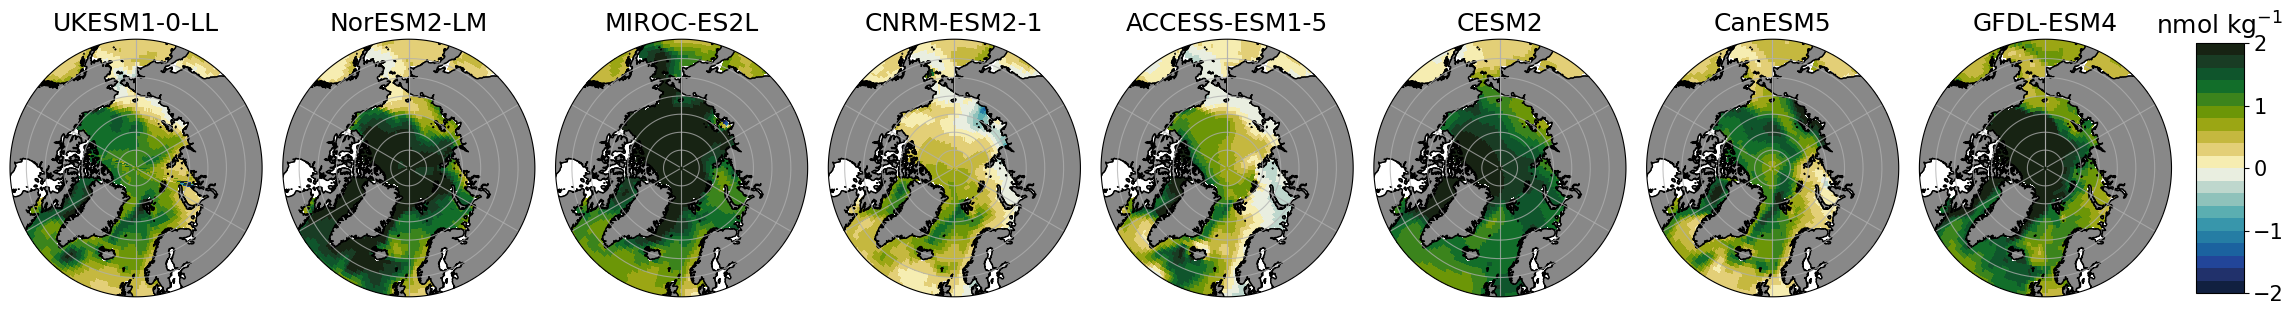

In [22]:
print('Plot the hysteresis areas for the individual models.....')
fig, ax = Plotter._plot_variable_for_individual_models(run_params,hyst_dict,da_name='normalized_hysteresis_area',vmin=0,vmax=.150,cmap=plt.get_cmap('cmo.amp',15),unit='-')
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_normalized_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)
    
fig, ax = Plotter._plot_variable_for_individual_models(run_params,hyst_dict,da_name='signed_hysteresis_area',vmin=-2,vmax=2,cmap=plt.get_cmap('cmo.delta',20),unit=r'nmol kg$^{-1}$')
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_signed_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)

Plot the hysteresis areas for the individual models (Global and Arctic together).....


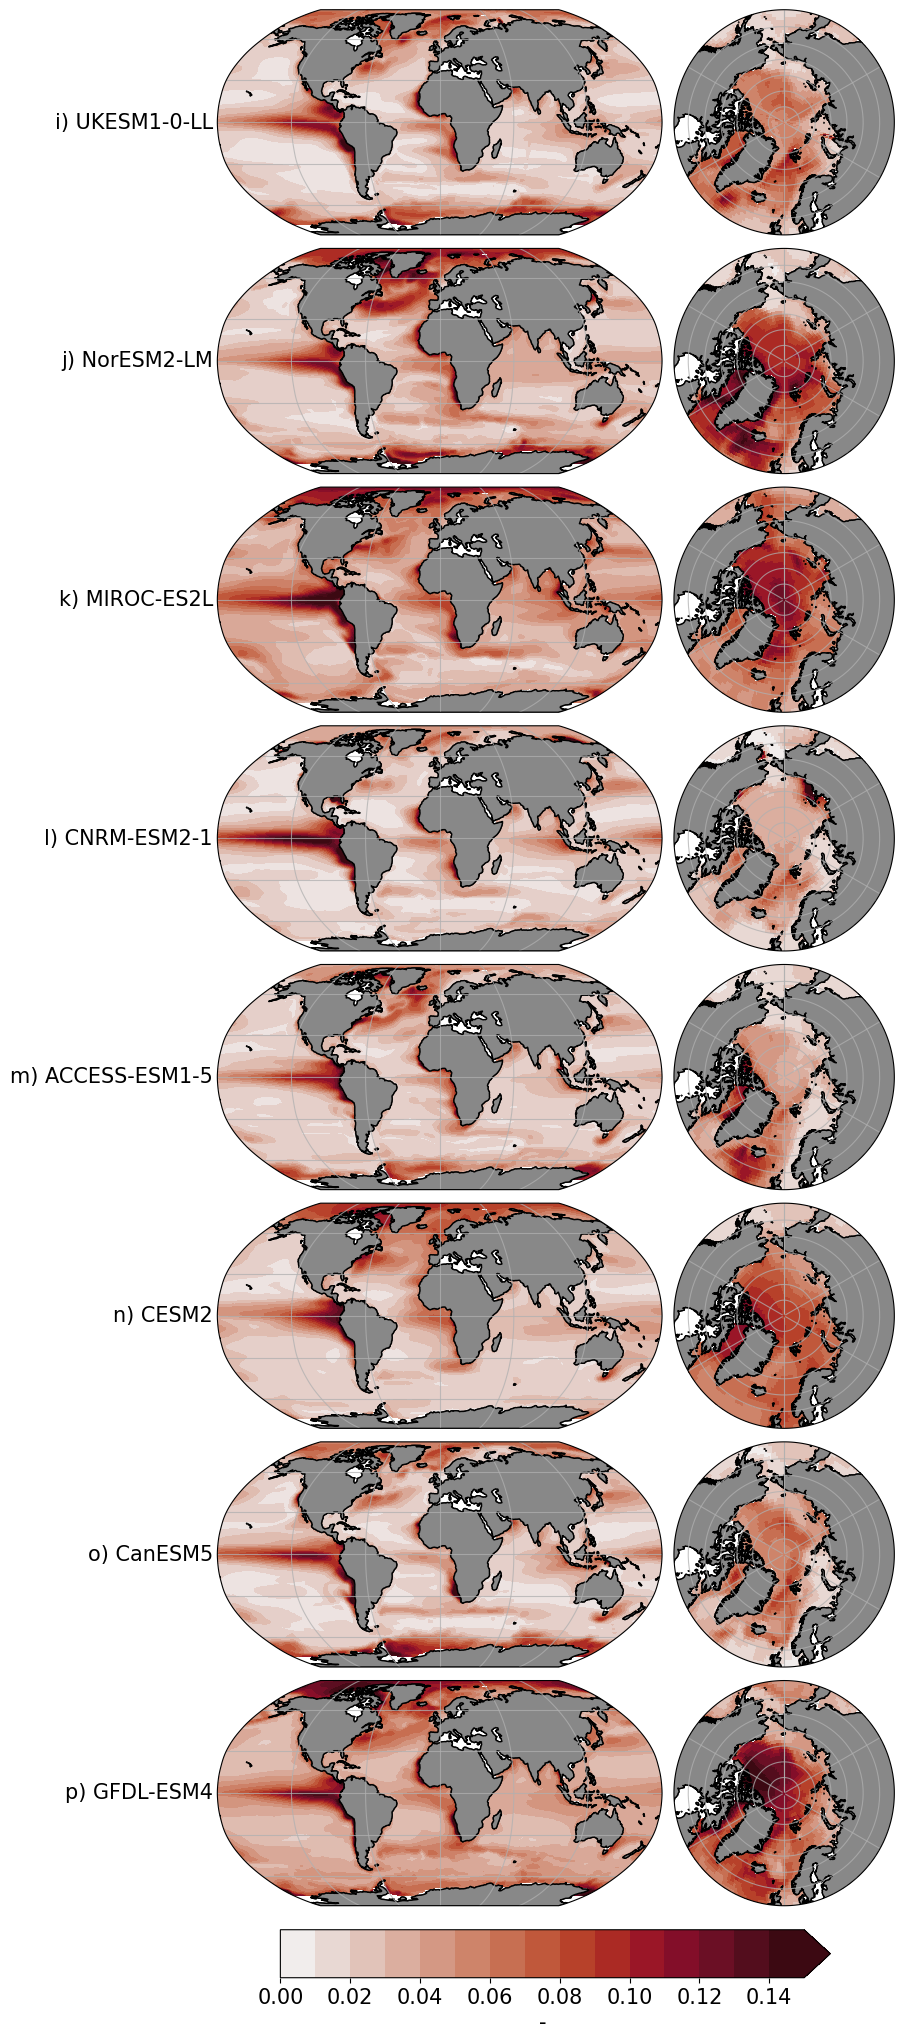

In [23]:
print('Plot the hysteresis areas for the individual models (Global and Arctic together).....')

fig = Plotter._plot_variable_for_individual_models_global_and_arctic(run_params,hyst_dict,da_name='normalized_hysteresis_area',vmin=0,vmax=.150,cmap=plt.get_cmap('cmo.amp',15),unit='-',col=2)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_and_arctic_hysteresis_normalized_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)

Plot the hysteresis areas for the individual models (Global and Arctic together).....


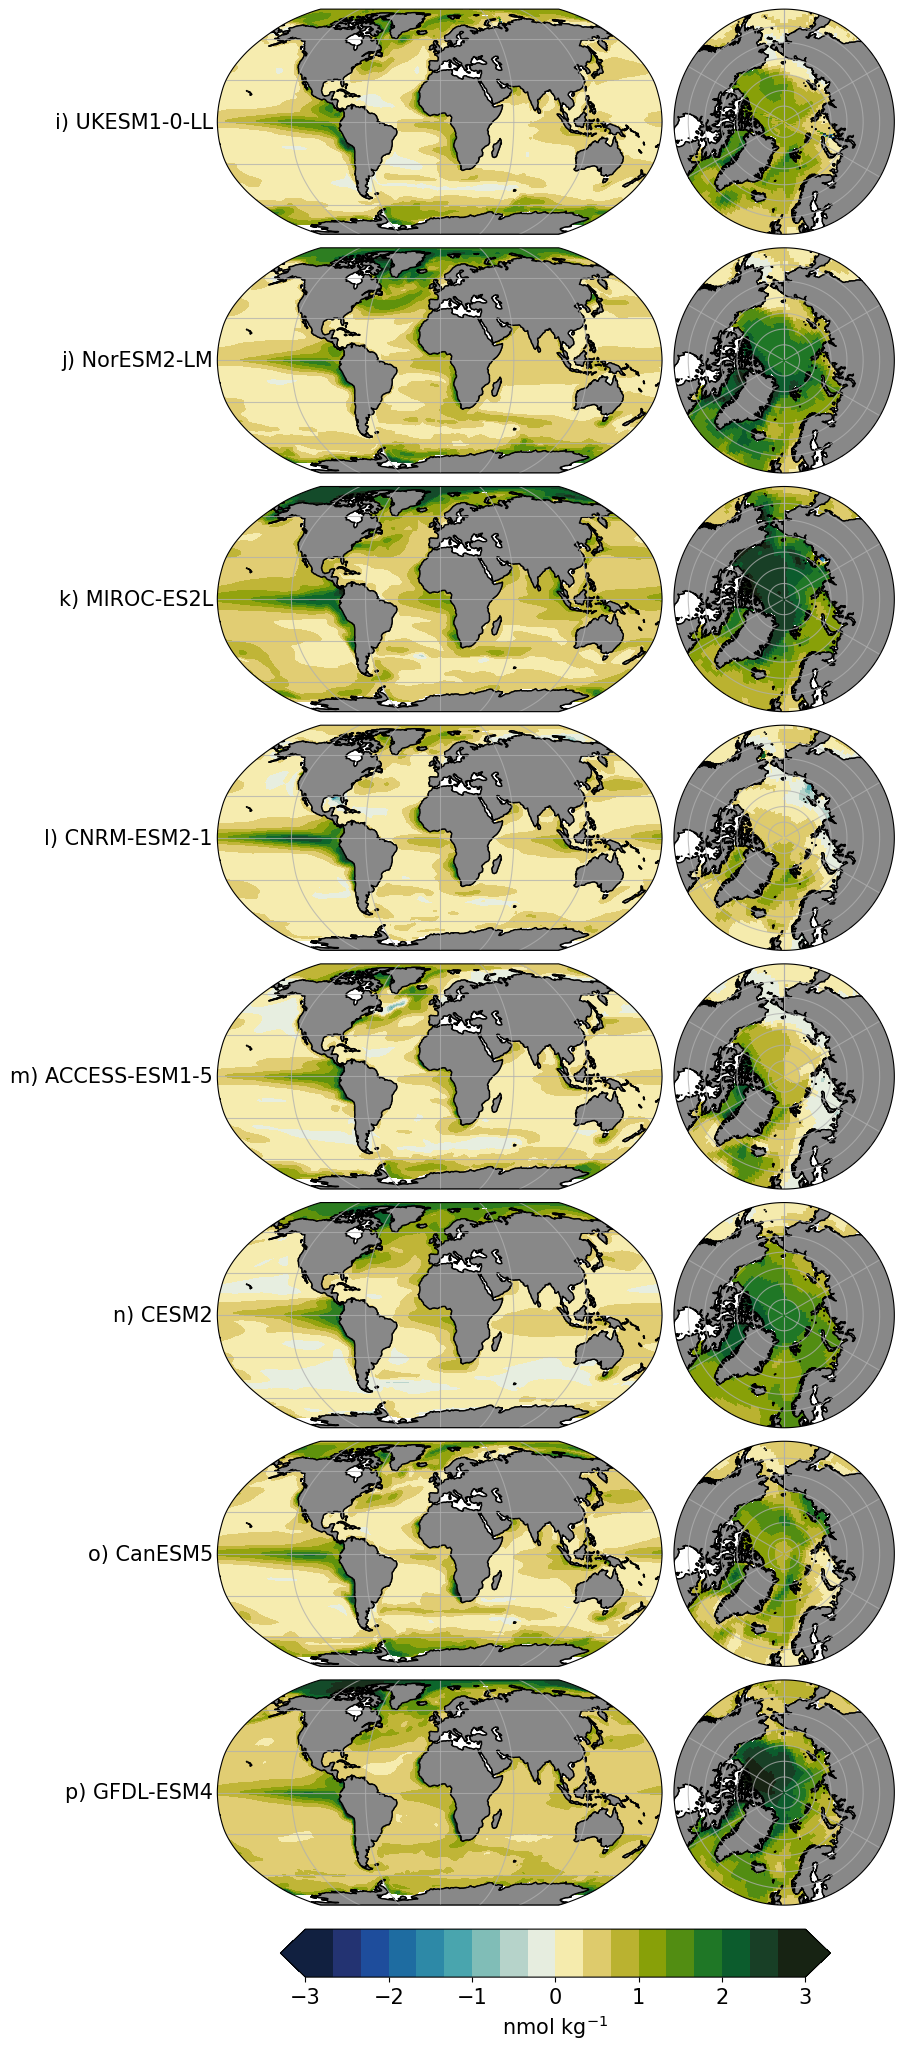

In [24]:
print('Plot the hysteresis areas for the individual models (Global and Arctic together).....')

fig = Plotter._plot_variable_for_individual_models_global_and_arctic(run_params,hyst_dict,da_name='signed_hysteresis_area',vmin=-3,vmax=3,cmap=plt.get_cmap('cmo.delta',18),unit=r'nmol kg$^{-1}$',col=2)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_and_arctic_hysteresis_signed_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)

## Plot the H+ difference between the end of rampdown (260-280) and the start of rampup (0-20) to see where there are largest changes

In [25]:
print('First calculate the time slice differences in sCT for each model......')
time_slice_difference = xr.Dataset()
for key in run_params.keys(): # loop over runs
    rampdown_end = ds_data[key][temporal_resolution].isel(year=slice(260,280)).mean(dim='year')
    rampup_start = ds_data[key][temporal_resolution].isel(year=slice(0,20)).mean(dim='year')
    time_slice_difference[key] = rampdown_end - rampup_start

print('.... and compute the multi-model mean and agreement')
time_slice_difference_mmm, time_slice_difference_agreement = MMFuncs._calc_multimodel_mean_and_agreement(time_slice_difference, da_name=None, agreement_type = 'sign', agreement_thresh='at_least_80percent_agree')



First calculate the time slice differences in sCT for each model......
.... and compute the multi-model mean and agreement


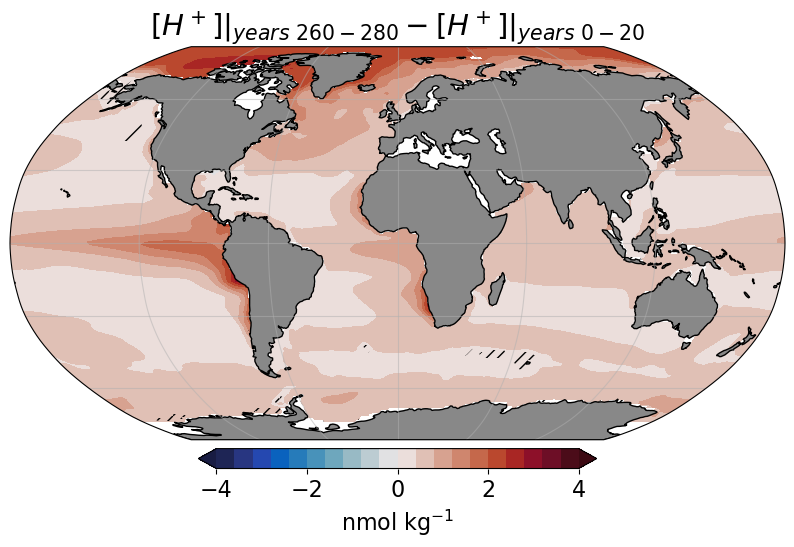

In [26]:
fig, ax = Plotter.plot_global_map(time_slice_difference_mmm,[],
                        -4,4,21,
                        plt.get_cmap('cmo.balance'),
                        [-4,-2,0,2,4],
                        'both',
                        r'nmol kg$^{-1}$',
                        r'$[H^+]|_{years\,\, 260-280} - [H^+]|_{years\,\, 0-20}$',
                        agreement=time_slice_difference_agreement)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_time_slice_difference_hplus.png',dpi=300,transparent=True)

In [27]:
central_arctic_diff = []
global_diff = []
for key in ['2','3','4','5','6','7','8','9']:
    central_arctic_diff.append(regional_time_series_2['central Arctic'][key].isel(year=280).values - regional_time_series_2['central Arctic'][key].isel(year=0).values)
    global_diff.append(regional_time_series_2['Global Ocean'][key].isel(year=280).values - regional_time_series_2['Global Ocean'][key].isel(year=0).values)
print('Central Arctic start end difference:')
print(f'{np.mean(central_arctic_diff)} +- {np.std(central_arctic_diff)}')
print('Global Ocean start end difference:')
print(f'{np.mean(global_diff)} +- {np.std(global_diff)}')


Central Arctic start end difference:
1.5956023267918873 +- 0.4912249589595306
Global Ocean start end difference:
0.39921986230890316 +- 0.026907637164536896
